# Indian Stocks Model Training

train 2 Ridge models for NIFTY 50 return prediction

- Short-term return: next 10 trading days
- Long-term return: next 250 trading days

Features used:
- 5-day momentum
- 20-day momentum
- 60-day momentum
- 20-day volatility

## Step 1: Import Required Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## Step 2: Fetch Historical Data

Download 10 years of NIFTY 50 index data from Yahoo Finance

In [2]:
print('Fetching NIFTY 50 historical data...')
stock = yf.Ticker('^NSEI')
df = stock.history(period='10y').reset_index()

print(f'Data fetched: {len(df)} rows')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
df.head()

Fetching NIFTY 50 historical data...
Data fetched: 2464 rows
Date range: 2016-04-04 to 2026-04-02


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2016-04-04 00:00:00+05:30,7733.149902,7764.450195,7704.399902,7758.799805,155500,0.0,0.0
1,2016-04-05 00:00:00+05:30,7736.299805,7736.299805,7588.649902,7603.200195,203800,0.0,0.0
2,2016-04-06 00:00:00+05:30,7636.049805,7638.649902,7591.750000,7614.350098,165600,0.0,0.0
3,2016-04-07 00:00:00+05:30,7630.399902,7630.750000,7535.850098,7546.450195,234400,0.0,0.0
4,2016-04-08 00:00:00+05:30,7542.350098,7569.350098,7526.700195,7555.200195,143400,0.0,0.0


## Step 3: Feature Engineering

Create scale-invariant momentum and volatility features:
- **Mom_5d**: 5-day price momentum (% change)
- **Mom_20d**: 20-day price momentum (% change)
- **Mom_60d**: 60-day price momentum (% change)
- **Volatility_20d**: 20-day rolling volatility (std of % changes)

In [3]:
print('Engineering features...')

# Momentum over last 5, 20, and 60 days
df['Mom_5d'] = df['Close'].pct_change(periods=5)
df['Mom_20d'] = df['Close'].pct_change(periods=20)
df['Mom_60d'] = df['Close'].pct_change(periods=60)
df['Volatility_20d'] = df['Close'].pct_change().rolling(window=20).std()

print('✓ Momentum and volatility features created')
print(f'\nFeature statistics:')
print(df[['Mom_5d', 'Mom_20d', 'Mom_60d', 'Volatility_20d']].describe())

Engineering features...
✓ Momentum and volatility features created

Feature statistics:
            Mom_5d      Mom_20d      Mom_60d  Volatility_20d
count  2459.000000  2444.000000  2404.000000     2444.000000
mean      0.002484     0.010166     0.032186        0.008674
std       0.022400     0.045773     0.080870        0.005275
min      -0.190239    -0.370057    -0.372431        0.003169
25%      -0.008896    -0.011635    -0.014192        0.005948
50%       0.003957     0.011910     0.039018        0.007407
75%       0.015259     0.037109     0.079629        0.009677
max       0.105221     0.202904     0.375907        0.055963


## Step 3.1: Quick Feature Visualization

Simple visual sanity checks for price, momentum, and volatility features.

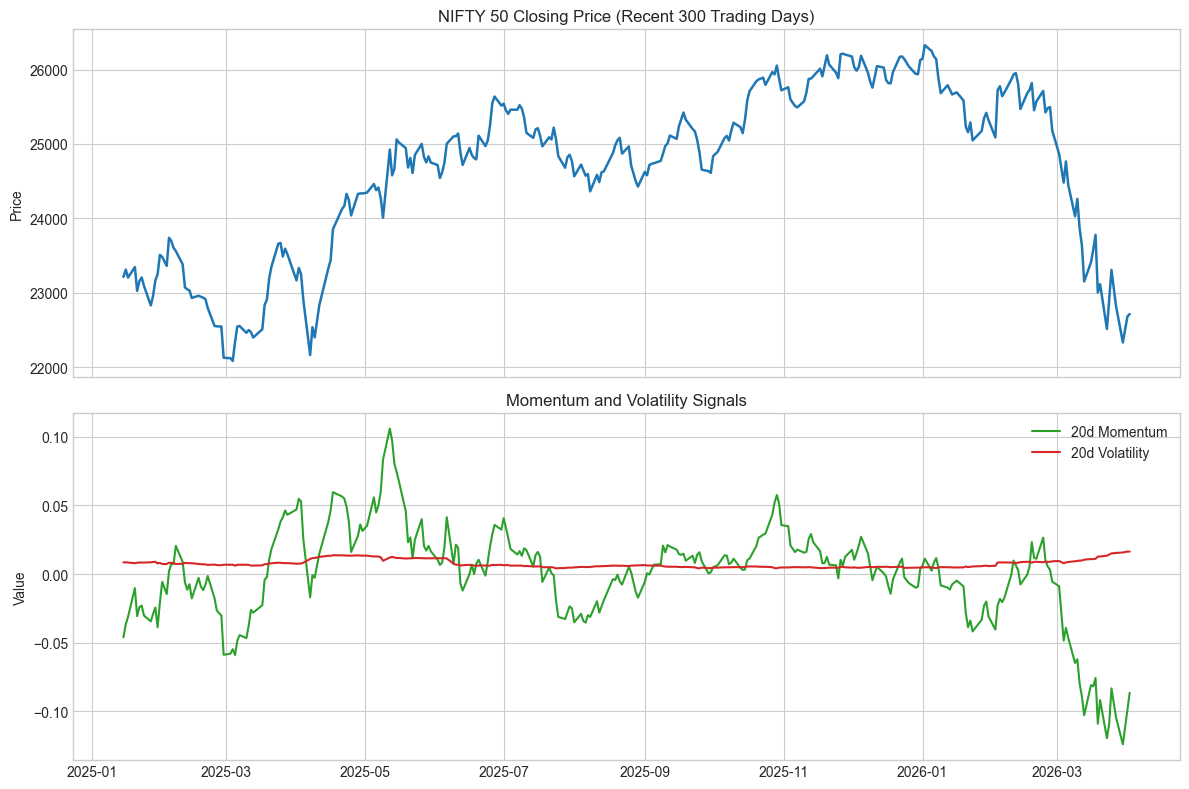

In [4]:
# Focus on recent history so plots stay readable
plot_df = df.dropna(subset=['Mom_5d', 'Mom_20d', 'Mom_60d', 'Volatility_20d']).copy().tail(300)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(plot_df['Date'], plot_df['Close'], color='#1f77b4', linewidth=1.8)
axes[0].set_title('NIFTY 50 Closing Price (Recent 300 Trading Days)')
axes[0].set_ylabel('Price')

axes[1].plot(plot_df['Date'], plot_df['Mom_20d'], label='20d Momentum', color='#2ca02c')
axes[1].plot(plot_df['Date'], plot_df['Volatility_20d'], label='20d Volatility', color='#d62728')
axes[1].set_title('Momentum and Volatility Signals')
axes[1].set_ylabel('Value')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 4: Target Engineering

Create dual prediction targets:
- **Target_Short_10d**: Next 10 trading days return (% change)
- **Target_Long_250d**: Next 250 trading days return (% change)

In [5]:
print('Engineering targets...')

# Short Term: Next 10 trading days (approx 2 weeks)
df['Target_Short_10d'] = df['Close'].shift(-10) / df['Close'] - 1

# Long Term: Next 250 trading days (approx 1 year)
df['Target_Long_250d'] = df['Close'].shift(-250) / df['Close'] - 1

print('✓ Target variables created')
print(f'\nTarget statistics:')
print(df[['Target_Short_10d', 'Target_Long_250d']].describe())

Engineering targets...
✓ Target variables created

Target statistics:
       Target_Short_10d  Target_Long_250d
count       2454.000000       2214.000000
mean           0.004981          0.141122
std            0.032116          0.159892
min           -0.307495         -0.326598
25%           -0.012036          0.044104
50%            0.006610          0.116983
75%            0.022861          0.208449
max            0.168035          0.911816


## Step 5: Data Cleaning

Remove NaN values created by feature/target engineering

In [6]:
print('Cleaning data...')
print(f'Rows before cleaning: {len(df)}')

df_clean = df.dropna()

print(f'Rows after cleaning: {len(df_clean)}')
print(f'Removed: {len(df) - len(df_clean)} rows with NaN values')
print('✓ Data is ready for training')

Cleaning data...
Rows before cleaning: 2464
Rows after cleaning: 2154
Removed: 310 rows with NaN values
✓ Data is ready for training


## Step 6: Prepare Training Data

In [7]:
# Shared Features X
X = df_clean[['Mom_5d', 'Mom_20d', 'Mom_60d', 'Volatility_20d']].values

# Targets y
y_short = df_clean['Target_Short_10d'].values
y_long = df_clean['Target_Long_250d'].values

print(f'Training samples: {len(X)}')
print(f'Features shape: {X.shape}')
print(f'Short-term target shape: {y_short.shape}')
print(f'Long-term target shape: {y_long.shape}')
print('✓ Data prepared for model training')

Training samples: 2154
Features shape: (2154, 4)
Short-term target shape: (2154,)
Long-term target shape: (2154,)
✓ Data prepared for model training


## Step 7: Train Short-Term Model

Ridge Regression model for 10-day ahead predictions

In [8]:
print('Training Short-Term Model (1-2 Weeks)...')

# Split data for validation
X_train, X_test, y_short_train, y_short_test = train_test_split(
    X, y_short, test_size=0.2, random_state=42
)

model_short = Ridge(alpha=1.0)
model_short.fit(X_train, y_short_train)

# Evaluate
y_short_pred = model_short.predict(X_test)
mse_short = mean_squared_error(y_short_test, y_short_pred)
r2_short = r2_score(y_short_test, y_short_pred)

print(f'✓ Model trained')
print(f'  MSE: {mse_short:.6f}')
print(f'  R² Score: {r2_short:.4f}')
print(f'\nModel coefficients:')
for feature, coef in zip(['Mom_5d', 'Mom_20d', 'Mom_60d', 'Volatility_20d'], model_short.coef_):
    print(f'  {feature}: {coef:.6f}')

Training Short-Term Model (1-2 Weeks)...
✓ Model trained
  MSE: 0.001044
  R² Score: 0.0031

Model coefficients:
  Mom_5d: 0.026451
  Mom_20d: 0.024535
  Mom_60d: -0.015630
  Volatility_20d: 0.036366


## Step 8: Train Long-Term Model

Ridge Regression model for 250-day ahead predictions

In [9]:
print('Training Long-Term Model (1-3 Years)...')

# Split data for validation
X_train, X_test, y_long_train, y_long_test = train_test_split(
    X, y_long, test_size=0.2, random_state=42
)

model_long = Ridge(alpha=1.0)
model_long.fit(X_train, y_long_train)

# Evaluate
y_long_pred = model_long.predict(X_test)
mse_long = mean_squared_error(y_long_test, y_long_pred)
r2_long = r2_score(y_long_test, y_long_pred)

print(f'✓ Model trained')
print(f'  MSE: {mse_long:.6f}')
print(f'  R² Score: {r2_long:.4f}')
print(f'\nModel coefficients:')
for feature, coef in zip(['Mom_5d', 'Mom_20d', 'Mom_60d', 'Volatility_20d'], model_long.coef_):
    print(f'  {feature}: {coef:.6f}')

Training Long-Term Model (1-3 Years)...
✓ Model trained
  MSE: 0.022198
  R² Score: 0.0811

Model coefficients:
  Mom_5d: 0.060498
  Mom_20d: -0.180206
  Mom_60d: -0.254563
  Volatility_20d: 0.529789


## Step 8.1: Model Diagnostics Plots

Quick diagnostics to visually inspect prediction quality for both horizons.

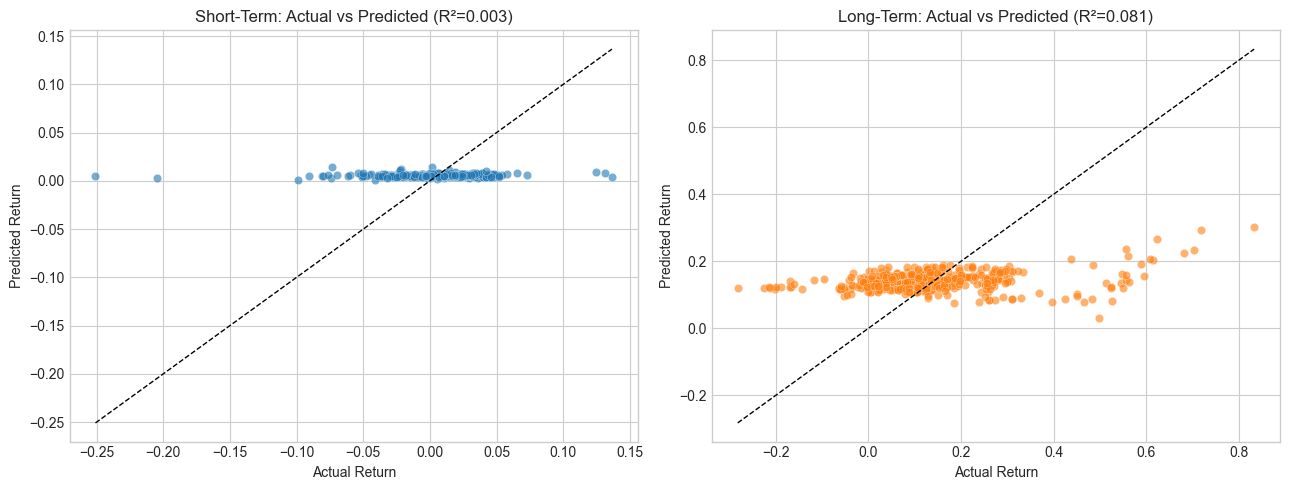

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Short-term diagnostics
axes[0].scatter(y_short_test, y_short_pred, alpha=0.6, color='#1f77b4', edgecolors='white', linewidth=0.3)
short_min = min(y_short_test.min(), y_short_pred.min())
short_max = max(y_short_test.max(), y_short_pred.max())
axes[0].plot([short_min, short_max], [short_min, short_max], '--', color='black', linewidth=1)
axes[0].set_title(f'Short-Term: Actual vs Predicted (R²={r2_short:.3f})')
axes[0].set_xlabel('Actual Return')
axes[0].set_ylabel('Predicted Return')

# Long-term diagnostics
axes[1].scatter(y_long_test, y_long_pred, alpha=0.6, color='#ff7f0e', edgecolors='white', linewidth=0.3)
long_min = min(y_long_test.min(), y_long_pred.min())
long_max = max(y_long_test.max(), y_long_pred.max())
axes[1].plot([long_min, long_max], [long_min, long_max], '--', color='black', linewidth=1)
axes[1].set_title(f'Long-Term: Actual vs Predicted (R²={r2_long:.3f})')
axes[1].set_xlabel('Actual Return')
axes[1].set_ylabel('Predicted Return')

plt.tight_layout()
plt.show()

## Step 9: Save Models

Export trained models as pickle files for use in the Streamlit application

In [11]:
print('Saving models to model folder...')

project_root = Path.cwd()
if project_root.name == 'notebook':
    project_root = project_root.parent

model_dir = project_root / 'model'
model_dir.mkdir(parents=True, exist_ok=True)

short_model_path = model_dir / 'model_short_term.pkl'
long_model_path = model_dir / 'model_long_term.pkl'

joblib.dump(model_short, short_model_path)
joblib.dump(model_long, long_model_path)

print('✓ Models saved successfully')
print(f'  -> {short_model_path}')
print(f'  -> {long_model_path}')
print('\nThese models are used by src/data_manager.py for predictions.')

Saving models to model folder...
✓ Models saved successfully
  -> /Users/vmangla/Documents/Vaibhav/indian-stocks-project/model/model_short_term.pkl
  -> /Users/vmangla/Documents/Vaibhav/indian-stocks-project/model/model_long_term.pkl

These models are used by src/data_manager.py for predictions.


## Step 10: Verify Model Predictions

Quick test of model predictions on latest data point

In [12]:
print('Testing model predictions on latest data...')

# Get latest data point
latest_row = df_clean.iloc[-1]
latest_features = [[latest_row['Mom_5d'], latest_row['Mom_20d'], 
                    latest_row['Mom_60d'], latest_row['Volatility_20d']]]

# Make predictions
pred_short_return = model_short.predict(latest_features)[0]
pred_long_return = model_long.predict(latest_features)[0]

# Calculate predicted prices
current_price = latest_row['Close']
pred_short_price = current_price * (1 + pred_short_return)
pred_long_price = current_price * (1 + pred_long_return)

print(f'Current NIFTY 50 Price: ₹{current_price:,.2f}')
print(f'\nShort-term (10 days ahead):')
print(f'  Predicted Return: {pred_short_return*100:.2f}%')
print(f'  Predicted Price: ₹{pred_short_price:,.2f}')
print(f'\nLong-term (250 days ahead):')
print(f'  Predicted Return: {pred_long_return*100:.2f}%')
print(f'  Predicted Price: ₹{pred_long_price:,.2f}')
print('\n✓ Models are working correctly!')

Testing model predictions on latest data...
Current NIFTY 50 Price: ₹23,486.85

Short-term (10 days ahead):
  Predicted Return: 0.76%
  Predicted Price: ₹23,664.33

Long-term (250 days ahead):
  Predicted Return: 14.53%
  Predicted Price: ₹26,900.09

✓ Models are working correctly!


## Summary

What this notebook does:
- Trains one short-term and one long-term Ridge model
- Uses momentum + volatility features
- Saves both `.pkl` files in the `model/` folder

Model files:
- `model/model_short_term.pkl`
- `model/model_long_term.pkl`

Runtime usage:
The Streamlit app loads these files from `src/config.py` inside `src/data_manager.py`.